# Model Training Notebook Template

> **Purpose:** Use this notebook to document the full machine learning model development process for your project.  
> It is designed as a **deliverable template** for the task and can be adapted for classification, regression, forecasting, recommendation, anomaly detection, or clustering problems.

---

## How to use this notebook
1. Duplicate this notebook for your project.
2. Rename the notebook model_training_notebook_<student_number>.ipynb
3. Replace all placeholders marked with `TODO`.
4. Keep the narrative concise but evidence-based.
5. Record each important experiment, metric, and decision.
6. Make sure the final notebook clearly shows:
   - the problem being solved
   - the data used
   - the baseline
   - the models tried
   - evaluation and validation
   - error analysis
   - iterations and improvements
   - the final recommendation and business value
7. Make sure the final notebook is saved in your individual GitHub repo.
8. Make sure the notebook meets the [notebook submission guidelines](https://adsai.buas.nl/General/NotebookSubmissionRules.html).

---

## Deliverable alignment
This notebook is structured to support the required deliverable:

- **Model training notebook**
- Evidence for:
  - **ILO 8.4 A:** why the model is an appropriate solution
  - **ILO 8.4 B:** metrics, validation performance, limitations, and common errors
  - **ILO 8.4 C:** key iterations and how they improved performance

## Individual Deliverable

Note this notebook should be completed individually. Each member of the group is responsible for training and analysing their own model. You are free to choose which model or models your team chooses to integrate into your application.
This submission should be unique if your submission is too similar to other members of your group or the class your case will be assessed for academic dishonesty and may be referred to the BOE.


## 0. Project metadata

Fill in this section before starting.

- **Project title:** `TODO`
- **Notebook owner / author:** `TODO`


## 1. Problem definition

### 1.1 Prediction or analysis task
Describe the specific problem your model will solve.

**Template prompts**
- What is the prediction or analysis task?
- What input data is available at prediction time?
- What output should the model produce?
- Who will use the model or its outputs?

**Write-up**
> TODO

### 1.2 Business or project value
Explain why solving this problem matters.

**Template prompts**
- What decision will this model support?
- What is improved if the model works well?
- What risks exist if it performs poorly?

**Write-up**
> TODO

### 1.3 Success criteria
Define what “good enough” means for this project.

**Template prompts**
- Which metric matters most and why?
- What threshold or comparative improvement would count as success?
- What constraints matter besides accuracy (e.g. interpretability, latency, fairness, recall, cost)?

**Write-up**
> TODO


## 2. Data selection and preparation

Document where the data came from, how it was prepared, and any key limitations. If you use multiple datasets you need to discuss all of them here.

### 2.1 Dataset summary
- **Data source(s):** `TODO`
- **Collection period:** `TODO`
- **Unit of analysis:** `TODO`  
  Example: one customer, one transaction, one image, one day, one text sample
- **Target variable:** `TODO`
- **Key features:** `TODO`
- **Important exclusions or filters:** `TODO`

### 2.2 Risks and limitations
- Missing values: `TODO`
- Sampling bias: `TODO`
- Label quality issues: `TODO`
- Leakage risks: `TODO`
- Ethical/privacy concerns: `TODO`


In [1]:
import pandas as pd
df = pd.read_csv('../../../data/processed/msft_merged.csv')

In [2]:
import pandas_market_calendars as mcal

# Align dataset dates (date-only) with calendar trading days
df["Date"] = pd.to_datetime(df["Date"]).dt.normalize()
df = df.sort_values("Date")

calendar = mcal.get_calendar("NYSE")
full_range = pd.date_range(df["Date"].min(), df["Date"].max(), freq="D")

trading_days = calendar.valid_days(
    start_date=full_range.min(),
    end_date=full_range.max(),
)
trading_days = pd.DatetimeIndex(trading_days.date)  # date-only, no tz

# Add missing non-trading dates and forward-fill market values
df = df.set_index("Date").reindex(full_range)
df.index.name = "Date"
df = df.sort_index().ffill()

# Flags on the full daily index
df["is_trading_day"] = df.index.isin(trading_days)
df["is_weekend"] = df.index.dayofweek >= 5
df["is_holiday"] = (~df["is_trading_day"]) & (~df["is_weekend"])

df = df.reset_index()

### 2.3 Initial data inspection

Summarise the dataset datasets after loading it.

- Number of rows: `TODO`
- Number of columns: `TODO`
- Target class balance / target distribution: `TODO`
- Data types overview: `TODO`
- Key issues noticed in the raw data: `TODO`


In [3]:
print(df.shape)
print(df.info())
df.head()

(4091, 13)
<class 'pandas.DataFrame'>
RangeIndex: 4091 entries, 0 to 4090
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            4091 non-null   datetime64[us]
 1   Open            4091 non-null   float64       
 2   High            4091 non-null   float64       
 3   Low             4091 non-null   float64       
 4   Close           4091 non-null   float64       
 5   Volume          4091 non-null   float64       
 6   gold_close      4091 non-null   float64       
 7   oil_close       4091 non-null   float64       
 8   vix             4091 non-null   float64       
 9   spy_close       4091 non-null   float64       
 10  is_trading_day  4091 non-null   bool          
 11  is_weekend      4091 non-null   bool          
 12  is_holiday      4091 non-null   bool          
dtypes: bool(3), datetime64[us](1), float64(9)
memory usage: 331.7 KB
None


,Date,Open,High,Low,Close,Volume,gold_close,oil_close,vix,spy_close,is_trading_day,is_weekend,is_holiday
0,2015-02-17,43.97,44.0000,43.19,43.580,33695149.0,1208.099976,53.529999,15.80,174.000732,True,False,False
1,2015-02-18,43.63,43.7000,43.39,43.530,27111657.0,1199.699951,52.139999,15.45,174.017288,True,False,False
2,2015-02-19,43.18,43.5263,43.05,43.500,27556420.0,1207.099976,51.160000,15.29,173.893082,True,False,False
3,2015-02-20,43.51,43.8800,43.29,43.855,29721133.0,1204.400024,50.340000,14.30,174.936493,True,False,False
4,2015-02-21,43.51,43.8800,43.29,43.855,29721133.0,1204.400024,50.340000,14.30,174.936493,False,True,False


In [4]:
# include rows with date only past January 1, 2024
df = df[df['Date'] >= '2023-01-01']
print(df.shape)

(1216, 13)


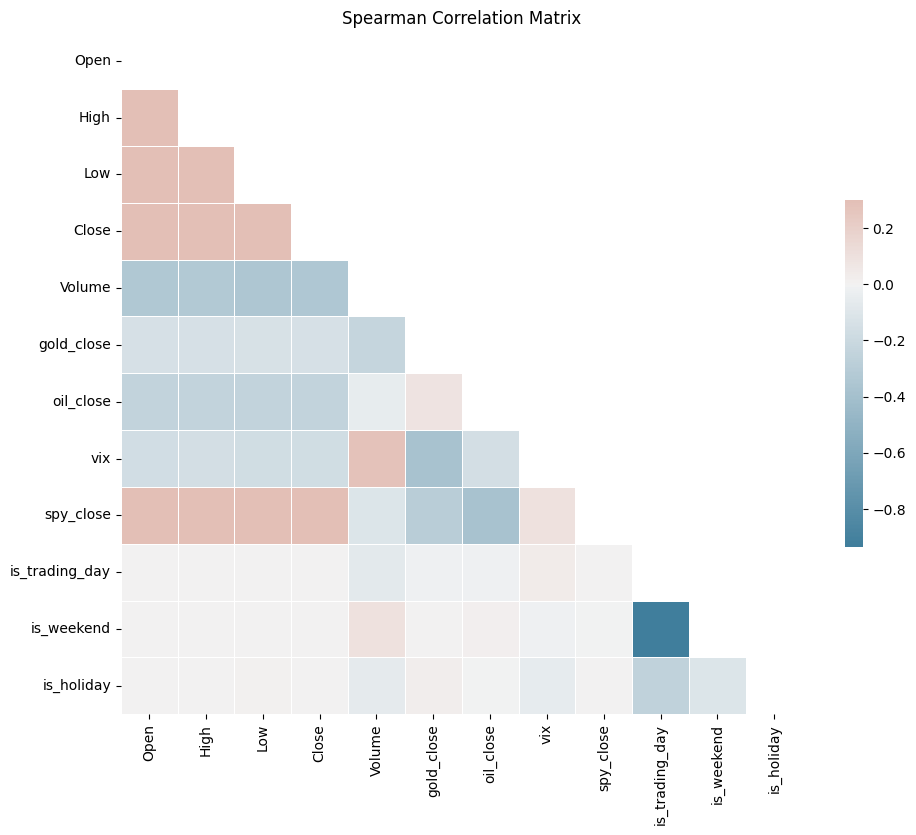

In [5]:
# create an appealing spearman correlation matrix and excluding 'date' column from dataframe 
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
# Calculate the correlation matrix
corr = df.iloc[:, 1:].corr(method='spearman')
# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))
# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(11, 9))
# Generate a custom diverging colormap
cmap = sns.diverging_palette(230, 20, as_cmap=True)
# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})
plt.title('Spearman Correlation Matrix')
plt.show()

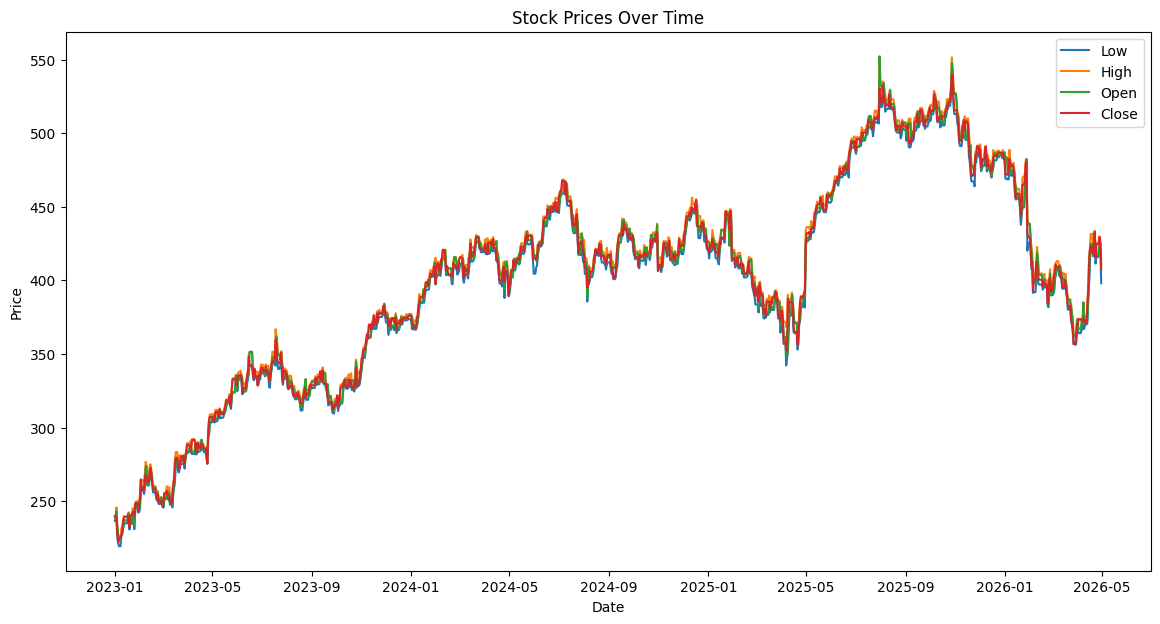

In [6]:
# plot the low, high, open, close prices over time
plt.figure(figsize=(14, 7))
plt.plot(df['Date'], df['Low'], label='Low')
plt.plot(df['Date'], df['High'], label='High')
plt.plot(df['Date'], df['Open'], label='Open')
plt.plot(df['Date'], df['Close'], label='Close')
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Stock Prices Over Time')
plt.legend()
plt.show()

### 2.4 Preprocessing decisions

Explain the preprocessing choices you made.

**Template prompts**
- How did you handle missing values?
- How did you encode categorical variables?
- Did you scale numeric features?
- Did you create new features?
- Did you remove features for leakage, irrelevance, or multicollinearity?
- Did you use a time-based split instead of a random split?
- Any other preprocessing steps?

**Write-up**
> TODO


In [7]:
# drop Volumne and vix columns. Create a new column "Direction" with 1 if the next day's closing price is higher than the current day's closing price, and 0 otherwise. The threshold value is 0.5% to account for minor fluctuations.
try:
    df = df.drop(columns=['oil_close', 'spy_close'])
except KeyError:
    pass

# add daily return and 5-day rolling mean
df['daily_return'] = df['Close'].pct_change()
df['rolling_mean_5'] = df['Close'].rolling(window=5, min_periods=1).mean()

# next-day close and direction using +/- 0.5% threshold
df['Close_next'] = df['Close'].shift(-1)
pct_change_next = (df['Close_next'] - df['Close']) / df['Close']
df['Direction'] = np.where(
    pct_change_next >= 0.005,
    1,
    np.where(pct_change_next <= -0.005, 0, np.nan),
)
df = df.dropna(subset=['Direction', 'Close_next']).copy()
df['Direction'] = df['Direction'].astype(int)
print(df.head())

           Date     Open      High       Low   Close      Volume   gold_close  \
2877 2023-01-03  243.080  245.7500  237.4000  239.58  25740036.0  1839.699951   
2878 2023-01-04  232.275  232.8700  225.9600  229.10  50623394.0  1852.800049   
2879 2023-01-05  227.200  227.5500  221.7602  222.31  39577823.0  1834.800049   
2882 2023-01-08  223.000  225.7601  219.3500  224.93  43613574.0  1864.199951   
2883 2023-01-09  226.450  231.2366  226.4100  227.12  27369784.0  1872.699951   

            vix  is_trading_day  is_weekend  is_holiday  daily_return  \
2877  22.900000            True       False       False     -0.001001   
2878  22.010000            True       False       False     -0.043743   
2879  22.459999            True       False       False     -0.029638   
2882  21.129999           False        True       False      0.000000   
2883  21.969999            True       False       False      0.009736   

      rolling_mean_5  Close_next  Direction  
2877         239.740      22

In [8]:
# check and handle missing values
missing_total = df.isna().sum().sum()
print(f"Total missing values: {missing_total}")
if missing_total > 0:
    numeric_cols = df.select_dtypes(include="number").columns
    non_numeric_cols = df.columns.difference(numeric_cols)
    df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
    for col in non_numeric_cols:
        mode_value = df[col].mode(dropna=True)
        if not mode_value.empty:
            df[col] = df[col].fillna(mode_value.iloc[0])
    print("Missing values filled.")

Total missing values: 0


In [9]:
pd.set_option('display.max_columns', None)
df.head()

,Date,Open,High,Low,Close,Volume,gold_close,vix,is_trading_day,is_weekend,is_holiday,daily_return,rolling_mean_5,Close_next,Direction
2877,2023-01-03,243.080,245.7500,237.4000,239.58,25740036.0,1839.699951,22.900000,True,False,False,-0.001001,239.740,229.10,0
2878,2023-01-04,232.275,232.8700,225.9600,229.10,50623394.0,1852.800049,22.010000,True,False,False,-0.043743,237.080,222.31,0
2879,2023-01-05,227.200,227.5500,221.7602,222.31,39577823.0,1834.800049,22.459999,True,False,False,-0.029638,234.126,224.93,1
2882,2023-01-08,223.000,225.7601,219.3500,224.93,43613574.0,1864.199951,21.129999,False,True,False,0.000000,225.240,227.12,1
2883,2023-01-09,226.450,231.2366,226.4100,227.12,27369784.0,1872.699951,21.969999,True,False,False,0.009736,224.844,228.85,1


## 3. Validation strategy

State clearly how you will validate model performance.

### 3.1 Chosen validation approach
Select the method that best matches your problem:
- Train/test split
- Cross-validation
- Stratified split
- Time-based validation
- Backtesting / rolling window validation
- Group-based split

**Justification**
> TODO: explain why this validation method is appropriate for your problem and data.

### 3.2 Leakage prevention
Explain how you reduced leakage risk.

**Write-up**
> TODO


In [10]:
# split data 80/20 for train/test
from sklearn.model_selection import train_test_split

date_series = df['Date'].copy()  # keep aside for splitting
X = df.drop(columns=['Date', 'Direction', 'Close_next'])
y_direction = df['Direction']  # classification target (up/down)
y_close = df['Close_next']  # regression target (next-day close)

X_train, X_test, y_close_train, y_close_test, y_dir_train, y_dir_test = train_test_split(
    X,
    y_close,
    y_direction,
    test_size=0.15,
    shuffle=False,
 )
print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set: {X_test.shape[0]} samples')

Training set: 474 samples
Test set: 84 samples


In [11]:
# scale features using training data only (avoid leakage)
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# scale Close using training data only for time-series models
close_scaler = RobustScaler()
train_close = df.loc[X_train.index, 'Close']
close_scaler.fit(train_close.to_numpy().reshape(-1, 1))

# full scaled dataframe for inspection (uses train-fitted scaler)
X_scaled = scaler.transform(X)
scaled_df = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)
scaled_df.insert(0, 'Date', df['Date'].to_numpy())
scaled_df['Close_next'] = df['Close_next'].to_numpy()
scaled_df['Direction'] = df['Direction'].to_numpy()

## 4. Baseline model

A baseline gives you something simple to compare against.

### 4.1 Baseline approach
Describe the baseline and why it is a reasonable minimum benchmark.

Examples:
- Predict the most frequent class
- Predict the mean/median target
- Previous-period value for forecasting
- Simple rule-based heuristic
- Existing manual process

**Write-up**
> TODO


In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report 

baseline_model = RandomForestClassifier(n_estimators=100, random_state=42)
baseline_model.fit(X_train_scaled, y_dir_train)
y_pred = baseline_model.predict(X_test_scaled)

In [13]:
print("Baseline Model Performance:")
print(classification_report(y_dir_test, y_pred))

Baseline Model Performance:
              precision    recall  f1-score   support

           0       0.43      0.23      0.30        43
           1       0.46      0.68      0.55        41

    accuracy                           0.45        84
   macro avg       0.45      0.46      0.43        84
weighted avg       0.45      0.45      0.42        84



### 4.2 Baseline results
Record the baseline performance here.

| Metric | Baseline result | Notes |
|---|---:|---|
| Primary metric | TODO | TODO |
| Secondary metric | TODO | TODO |
| Other metric | TODO | TODO |

**Interpretation**
> TODO: explain what the baseline tells you.


## 5. Candidate models

List the models you plan to try and why they are appropriate.

| Model | Why this model is suitable | Key strengths | Main risks / limitations |
|---|---|---|---|
| LSTM | Suitable, becuase of "memory cells" architecture | Memory | Computational Power |
| ARIMA | Suitable, because forecasts short term fluctuations | Perfect for next-day movement forecast | Requires linear data |
| Prophet | Suitable, because it models trends and seasonality with holidays | Interpretable trend/seasonality | Can underfit sudden regime shifts |

**Selection rationale**
> TODO


## 6. Evaluation framework

Before training, define the metrics you will use and why.

### 6.1 Primary metric
Choose the main metric used to compare models.

**Examples**
- Classification: F1, recall, precision, ROC-AUC, PR-AUC, balanced accuracy
- Regression: RMSE, MAE, R², MAPE
- Forecasting: MAE, RMSE, sMAPE, MASE
- Ranking/recommendation: MAP@K, Recall@K, NDCG

**Justification**
> TODO

### 6.2 Secondary metrics
Add supporting metrics that capture other aspects of performance.

**Write-up**
> TODO


## 7. Train and evaluate models

Train each candidate model and compare results systematically.


In [14]:
# implement Prophet model to forecast Close, then derive Direction
from prophet import Prophet
import numpy as np
from sklearn.metrics import classification_report

def direction_from_change(pct_change, threshold=0.005):
    return np.where(
        pct_change >= threshold,
        1,
        np.where(pct_change <= -threshold, 0, np.nan),
    )

train_prophet = pd.DataFrame({
    'ds': df.loc[X_train.index, 'Date'],
    'y': close_scaler.transform(df.loc[X_train.index, 'Close'].to_numpy().reshape(-1, 1)).ravel(),
})
prophet_model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=False,
 )
prophet_model.fit(train_prophet)

future_df = prophet_model.make_future_dataframe(periods=len(X_test), freq="D")
forecast = prophet_model.predict(future_df)
prophet_pred_close_scaled = forecast['yhat'].tail(len(X_test)).to_numpy()
prophet_pred_close = close_scaler.inverse_transform(prophet_pred_close_scaled.reshape(-1, 1)).ravel()

test_close_current = df.loc[X_test.index, 'Close'].to_numpy()
test_close_next = df.loc[X_test.index, 'Close_next'].to_numpy()
prophet_dates = df.loc[X_test.index, 'Date'].to_numpy()

pred_pct_change = (prophet_pred_close - test_close_current) / test_close_current
true_pct_change = (test_close_next - test_close_current) / test_close_current

prophet_pred = direction_from_change(pred_pct_change)
prophet_true = direction_from_change(true_pct_change)

prophet_mask = ~np.isnan(prophet_true) & ~np.isnan(prophet_pred)
print("Prophet Model Performance (Direction from forecasted Close):")
print(classification_report(prophet_true[prophet_mask].astype(int), prophet_pred[prophet_mask].astype(int)))

c:\Users\angel\AppData\Local\pypoetry\Cache\virtualenvs\2025-26d-fai1-adsai-group-15-Gmc8at2I-py3.13\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
16:49:38 - cmdstanpy - INFO - Chain [1] start processing
16:49:38 - cmdstanpy - INFO - Chain [1] done processing


Prophet Model Performance (Direction from forecasted Close):
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        43
           1       0.49      1.00      0.66        41

    accuracy                           0.49        84
   macro avg       0.24      0.50      0.33        84
weighted avg       0.24      0.49      0.32        84



c:\Users\angel\AppData\Local\pypoetry\Cache\virtualenvs\2025-26d-fai1-adsai-group-15-Gmc8at2I-py3.13\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\angel\AppData\Local\pypoetry\Cache\virtualenvs\2025-26d-fai1-adsai-group-15-Gmc8at2I-py3.13\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\angel\AppData\Local\pypoetry\Cache\virtualenvs\2025-26d-fai1-adsai-group-15-Gmc8at2I-py3.13\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill

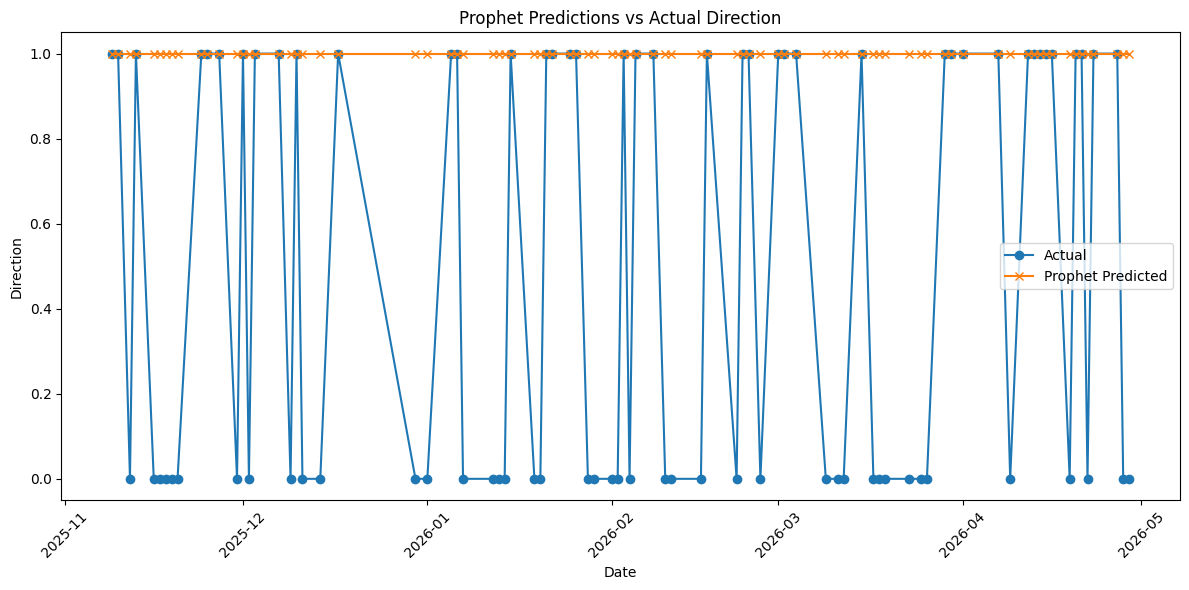

In [15]:
# plot the graph of Prophet predictions vs actual Direction values
import matplotlib.dates as mdates

plt.figure(figsize=(12, 6))
plt.plot(prophet_dates[prophet_mask], prophet_true[prophet_mask], label='Actual', marker='o')
plt.plot(prophet_dates[prophet_mask], prophet_pred[prophet_mask], label='Prophet Predicted', marker='x')
plt.xlabel('Date')
plt.ylabel('Direction')
plt.title('Prophet Predictions vs Actual Direction')
plt.legend()
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---
ARIMA model


In [34]:
# implement SARIMA model with auto_arima, forecast Close, then derive Direction
import numpy as np
from pmdarima import auto_arima
from sklearn.metrics import classification_report

def direction_from_change(pct_change, threshold=0.005):
    return np.where(
        pct_change >= threshold,
        1,
        np.where(pct_change <= -threshold, 0, np.nan),
    )

train_close_scaled = close_scaler.transform(df.loc[X_train.index, 'Close'].to_numpy().reshape(-1, 1)).ravel()
test_close_current = df.loc[X_test.index, 'Close'].to_numpy()
test_close_next = df.loc[X_test.index, 'Close_next'].to_numpy()

sarima_model = auto_arima(
    train_close_scaled,
    seasonal=True,
    m=7,
    start_p=0, start_q=0,
    max_p=3, max_q=3,
    start_P=0, start_Q=0,
    max_P=2, max_Q=2,
    d=None, D=None,
    stepwise=True,
    suppress_warnings=True,
    error_action="ignore",
    trace=False,
)
print(f"Best SARIMA order: {sarima_model.order}, seasonal order: {sarima_model.seasonal_order}")

sarima_forecast_scaled = sarima_model.predict(n_periods=len(X_test))
sarima_forecast = close_scaler.inverse_transform(np.asarray(sarima_forecast_scaled).reshape(-1, 1)).ravel()

pred_pct_change = (sarima_forecast - test_close_current) / test_close_current
true_pct_change = (test_close_next - test_close_current) / test_close_current

sarima_pred = direction_from_change(pred_pct_change)
sarima_true = direction_from_change(true_pct_change)

mask = ~np.isnan(sarima_true) & ~np.isnan(sarima_pred)
print("SARIMA Model Performance (Direction from forecasted Close):")
print(classification_report(sarima_true[mask].astype(int), sarima_pred[mask].astype(int)))

Best SARIMA order: (0, 1, 0), seasonal order: (0, 0, 0, 7)
SARIMA Model Performance (Direction from forecasted Close):
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        41
           1       0.49      1.00      0.66        40

    accuracy                           0.49        81
   macro avg       0.25      0.50      0.33        81
weighted avg       0.24      0.49      0.33        81



c:\Users\angel\AppData\Local\pypoetry\Cache\virtualenvs\2025-26d-fai1-adsai-group-15-Gmc8at2I-py3.13\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\angel\AppData\Local\pypoetry\Cache\virtualenvs\2025-26d-fai1-adsai-group-15-Gmc8at2I-py3.13\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\angel\AppData\Local\pypoetry\Cache\virtualenvs\2025-26d-fai1-adsai-group-15-Gmc8at2I-py3.13\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill

### 7.1 Model comparison summary

| Model | Primary metric | Secondary metrics | Better than baseline? | Notes |
|---|---:|---|---|---|
| Baseline | TODO | TODO | — | TODO |
| Model 1 | TODO | TODO | TODO | TODO |
| Model 2 | TODO | TODO | TODO | TODO |
| Model 3 | TODO | TODO | TODO | TODO |

**Interpretation**
> TODO: explain which model(s) look most promising and why.


In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import numpy as np

# Use robust-scaled features from the train/test split
X_train_scaled = np.asarray(X_train_scaled)
X_test_scaled = np.asarray(X_test_scaled)

# Create sequences for Close forecasting
def create_sequences_with_current_close(X, y_close, current_close, time_steps=1):
    Xs, ys, cs = [], [], []
    for i in range(len(X) - time_steps):
        v = X[i:(i + time_steps)]
        Xs.append(v)
        ys.append(y_close.iloc[i + time_steps])
        cs.append(current_close.iloc[i + time_steps - 1])
    return np.array(Xs), np.array(ys), np.array(cs)

# Build sequences for multiple time steps
TIME_STEPS_LIST = [30, 60, 90] 
max_steps = min(len(X_train_scaled), len(X_test_scaled)) - 1
TIME_STEPS_LIST = [s for s in TIME_STEPS_LIST if s <= max_steps]
if not TIME_STEPS_LIST:
    raise ValueError(f"No valid time_steps <= {max_steps}. Reduce TIME_STEPS_LIST.")
sequences_by_steps = {}
current_close_train = df.loc[X_train.index, 'Close'].reset_index(drop=True)
current_close_test = df.loc[X_test.index, 'Close'].reset_index(drop=True)
y_close_train_reset = y_close_train.reset_index(drop=True)
y_close_test_reset = y_close_test.reset_index(drop=True)
for steps in TIME_STEPS_LIST:
    X_train_seq_ts, y_train_close_ts, close_train_current_ts = create_sequences_with_current_close(
        X_train_scaled,
        y_close_train_reset,
        current_close_train,
        steps,
    )
    X_test_seq_ts, y_test_close_ts, close_test_current_ts = create_sequences_with_current_close(
        X_test_scaled,
        y_close_test_reset,
        current_close_test,
        steps,
    )
    sequences_by_steps[steps] = (
        X_train_seq_ts,
        y_train_close_ts,
        close_train_current_ts,
        X_test_seq_ts,
        y_test_close_ts,
        close_test_current_ts,
    )

# Default time steps for the baseline LSTM below
TIME_STEPS = TIME_STEPS_LIST[0]
(
    X_train_seq,
    y_train_close,
    close_train_current,
    X_test_seq,
    y_test_close,
    close_test_current,
) = sequences_by_steps[TIME_STEPS]

print(f"Time steps options: {TIME_STEPS_LIST}")
print(f"Default time steps: {TIME_STEPS}")
print(f"Train sequences: {X_train_seq.shape}")
print(f"Test sequences: {X_test_seq.shape}")

Time steps options: [30, 60]
Default time steps: 30
Train sequences: (444, 30, 12)
Test sequences: (54, 30, 12)


In [18]:
# Build LSTM model
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

model = Sequential()
model.add(LSTM(64, return_sequences=True, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])))
model.add(Dropout(0.2))
model.add(LSTM(32, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

c:\Users\angel\AppData\Local\pypoetry\Cache\virtualenvs\2025-26d-fai1-adsai-group-15-Gmc8at2I-py3.13\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [19]:
# train the LSTM model
history = model.fit(
    X_train_seq,
    y_train_close,
    epochs=30,
    batch_size=32,
    validation_data=(X_test_seq, y_test_close),
)

Epoch 1/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - loss: 162137.2188 - mae: 397.4648 - val_loss: 165717.8125 - val_mae: 406.1638
Epoch 2/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 160352.8906 - mae: 395.1956 - val_loss: 163307.8125 - val_mae: 403.1775
Epoch 3/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 157804.4844 - mae: 391.9449 - val_loss: 161241.4375 - val_mae: 400.6031
Epoch 4/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 156182.1562 - mae: 389.8554 - val_loss: 160093.6875 - val_mae: 399.1687
Epoch 5/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 155359.8594 - mae: 388.8254 - val_loss: 159483.1094 - val_mae: 398.4034
Epoch 6/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 154791.6406 - mae: 388.0718 - val_loss: 159002.4844 - val_mae: 397.7998
Epoch 7/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 154401.1875 - mae: 387.5999 - val_loss: 158565.4688 - val_mae: 397.2501
Epoch 8/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 153810.2812 - mae: 386.8

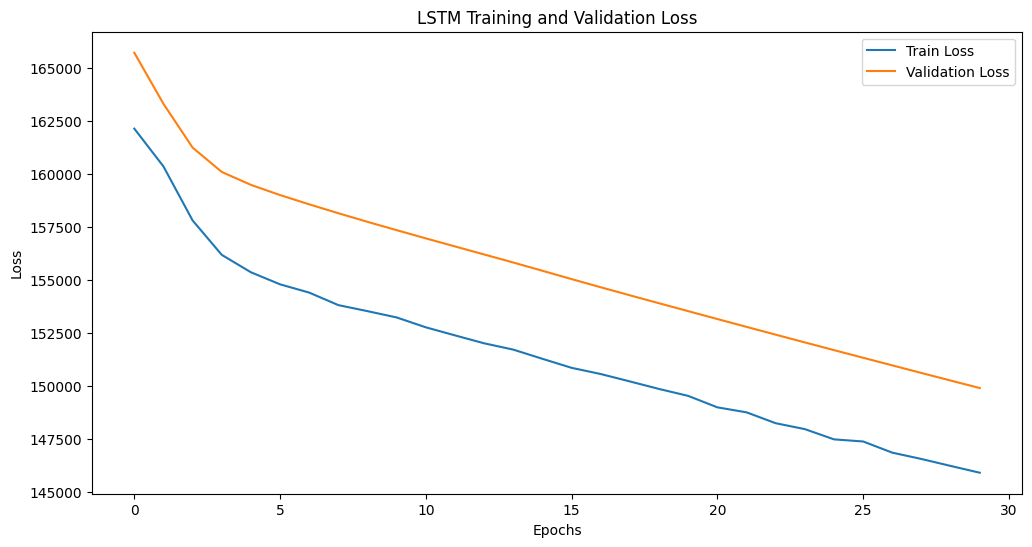

In [20]:
# plot the training and validation loss
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('LSTM Training and Validation Loss')
plt.legend()
plt.show()

In [21]:
# classification report for lstm model using Direction derived from forecasted Close
from sklearn.metrics import classification_report

def direction_from_change(pct_change, threshold=0.005):
    return np.where(
        pct_change >= threshold,
        1,
        np.where(pct_change <= -threshold, 0, np.nan),
    )

y_pred_close = model.predict(X_test_seq).ravel()
pred_pct_change = (y_pred_close - close_test_current) / close_test_current
true_pct_change = (y_test_close - close_test_current) / close_test_current

lstm_pred = direction_from_change(pred_pct_change)
lstm_true = direction_from_change(true_pct_change)

mask = ~np.isnan(lstm_true) & ~np.isnan(lstm_pred)
print("LSTM Model Performance (Direction from forecasted Close):")
print(classification_report(lstm_true[mask].astype(int), lstm_pred[mask].astype(int)))

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 306ms/step
LSTM Model Performance (Direction from forecasted Close):
              precision    recall  f1-score   support

           0       0.59      1.00      0.74        27
           1       0.00      0.00      0.00        19

    accuracy                           0.59        46
   macro avg       0.29      0.50      0.37        46
weighted avg       0.34      0.59      0.43        46



c:\Users\angel\AppData\Local\pypoetry\Cache\virtualenvs\2025-26d-fai1-adsai-group-15-Gmc8at2I-py3.13\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\angel\AppData\Local\pypoetry\Cache\virtualenvs\2025-26d-fai1-adsai-group-15-Gmc8at2I-py3.13\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\angel\AppData\Local\pypoetry\Cache\virtualenvs\2025-26d-fai1-adsai-group-15-Gmc8at2I-py3.13\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill

## 8. Iteration and improvement

This section should show how you refined your approach over time.

Typical improvements:
- alternative algorithms
- hyperparameter tuning
- feature engineering
- better preprocessing
- class balancing
- threshold tuning
- regularisation changes
- better handling of missing data
- different validation setup

Record each meaningful iteration.


In [22]:
# Hyperparameter optimization with Optuna for LSTM (Close forecasting)
import optuna
import numpy as np
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

optuna.logging.set_verbosity(optuna.logging.WARNING)
np.random.seed(42)

def build_lstm_model(trial, input_shape):
    n_layers = trial.suggest_int("n_layers", 1, 3)
    model = Sequential()
    for i in range(n_layers):
        units = trial.suggest_int(f"units_l{i}", 16, 128, step=16)
        dropout = trial.suggest_float(f"dropout_l{i}", 0.1, 0.5)
        return_sequences = i < n_layers - 1
        if i == 0:
            model.add(LSTM(units, return_sequences=return_sequences, input_shape=input_shape))
        else:
            model.add(LSTM(units, return_sequences=return_sequences))
        model.add(Dropout(dropout))
    model.add(Dense(1))
    lr = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)
    model.compile(optimizer=Adam(learning_rate=lr), loss="mse", metrics=["mae"])
    return model

def objective(trial):
    time_steps = trial.suggest_categorical("time_steps", TIME_STEPS_LIST)
    (
        X_train_seq_ts,
        y_train_close_ts,
        _close_train_current_ts,
        _X_test_seq_ts,
        _y_test_close_ts,
        _close_test_current_ts,
    ) = sequences_by_steps[time_steps]

    split_idx = int(len(X_train_seq_ts) * 0.8)
    X_tr, X_val = X_train_seq_ts[:split_idx], X_train_seq_ts[split_idx:]
    y_tr, y_val = y_train_close_ts[:split_idx], y_train_close_ts[split_idx:]

    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])
    model = build_lstm_model(trial, (X_tr.shape[1], X_tr.shape[2]))
    early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
    model.fit(
        X_tr,
        y_tr,
        validation_data=(X_val, y_val),
        epochs=20,
        batch_size=batch_size,
        verbose=0,
        callbacks=[early_stop],
    )
    val_loss, val_mae = model.evaluate(X_val, y_val, verbose=0)
    return float(val_mae)

In [23]:
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=10, show_progress_bar=True)

print("Best hyperparameters:")
print(study.best_params)
print(f"Best CV MAE: {study.best_value:.4f}")

  0%|          | 0/10 [00:00<?, ?it/s]c:\Users\angel\AppData\Local\pypoetry\Cache\virtualenvs\2025-26d-fai1-adsai-group-15-Gmc8at2I-py3.13\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
Best trial: 9. Best value: 413.309: 100%|██████████| 10/10 [01:55<00:00, 11.52s/it]

Best hyperparameters:
{'time_steps': 60, 'batch_size': 16, 'n_layers': 3, 'units_l0': 80, 'dropout_l0': 0.4139727243931428, 'units_l1': 16, 'dropout_l1': 0.29910966592679633, 'units_l2': 128, 'dropout_l2': 0.4756184577899495, 'learning_rate': 0.0013824034432598977}
Best CV MAE: 413.3087


In [24]:
# display the number of 0 and 1 in direction column
direction_counts = df['Direction'].value_counts()
print("Direction value counts:")
print(direction_counts)

Direction value counts:
Direction
1    302
0    256
Name: count, dtype: int64


In [25]:
# Train a final model using the best hyperparameters
best_params = study.best_params
best_model = Sequential()
n_layers = best_params["n_layers"]
best_time_steps = best_params["time_steps"]
(
    X_train_seq_best,
    y_train_close_best,
    close_train_current_best,
    X_test_seq_best,
    y_test_close_best,
    close_test_current_best,
) = sequences_by_steps[best_time_steps]
for i in range(n_layers):
    units = best_params[f"units_l{i}"]
    dropout = best_params[f"dropout_l{i}"]
    return_sequences = i < n_layers - 1
    if i == 0:
        best_model.add(LSTM(units, return_sequences=return_sequences, input_shape=(X_train_seq_best.shape[1], X_train_seq_best.shape[2])))
    else:
        best_model.add(LSTM(units, return_sequences=return_sequences))
    best_model.add(Dropout(dropout))
best_model.add(Dense(1))
best_model.compile(
    optimizer=Adam(learning_rate=best_params["learning_rate"]),
    loss="mse",
    metrics=["mae"],
)

c:\Users\angel\AppData\Local\pypoetry\Cache\virtualenvs\2025-26d-fai1-adsai-group-15-Gmc8at2I-py3.13\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [26]:
early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
best_model.fit(
    X_train_seq_best,
    y_train_close_best,
    validation_data=(X_test_seq_best, y_test_close_best),
    epochs=20,
    batch_size=best_params["batch_size"],
    verbose=0,
    callbacks=[early_stop],
)

In [27]:
# Test performance using Direction derived from forecasted Close
import numpy as np
from sklearn.metrics import classification_report

def direction_from_change(pct_change, threshold=0.005):
    return np.where(
        pct_change >= threshold,
        1,
        np.where(pct_change <= -threshold, 0, np.nan),
    )

y_test_pred_close = best_model.predict(X_test_seq_best, verbose=0).ravel()
pred_pct_change = (y_test_pred_close - close_test_current_best) / close_test_current_best
true_pct_change = (y_test_close_best - close_test_current_best) / close_test_current_best

best_pred = direction_from_change(pred_pct_change)
best_true = direction_from_change(true_pct_change)

mask = ~np.isnan(best_true) & ~np.isnan(best_pred)
print("Optimized LSTM test performance (Direction from forecasted Close):")
print(f"Best time steps: {best_time_steps}")
print(classification_report(best_true[mask].astype(int), best_pred[mask].astype(int)))

Optimized LSTM test performance (Direction from forecasted Close):
Best time steps: 60
              precision    recall  f1-score   support

           0       0.52      1.00      0.69        11
           1       0.00      0.00      0.00        10

    accuracy                           0.52        21
   macro avg       0.26      0.50      0.34        21
weighted avg       0.27      0.52      0.36        21



c:\Users\angel\AppData\Local\pypoetry\Cache\virtualenvs\2025-26d-fai1-adsai-group-15-Gmc8at2I-py3.13\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\angel\AppData\Local\pypoetry\Cache\virtualenvs\2025-26d-fai1-adsai-group-15-Gmc8at2I-py3.13\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\angel\AppData\Local\pypoetry\Cache\virtualenvs\2025-26d-fai1-adsai-group-15-Gmc8at2I-py3.13\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill

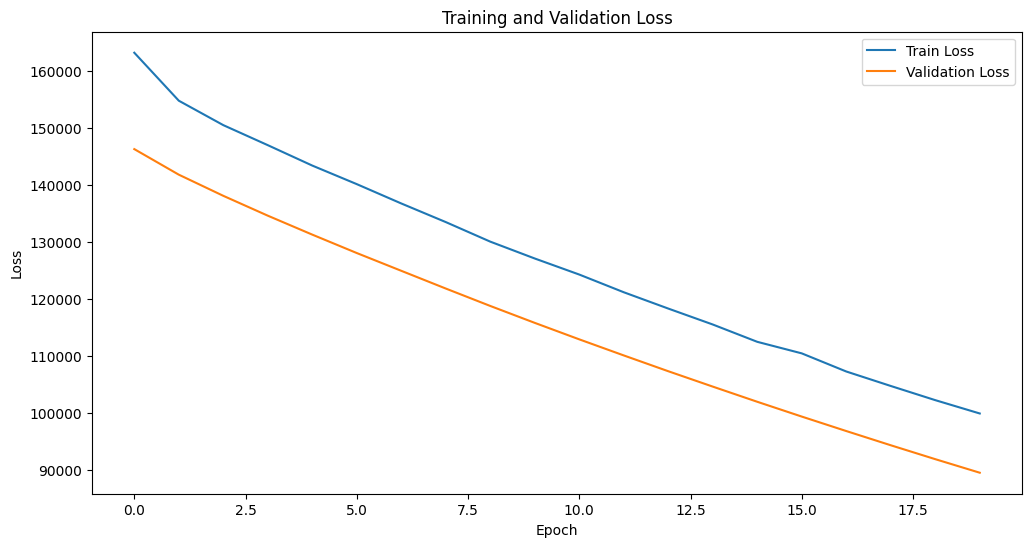

In [28]:
# plot the training graph of the optimized LSTM model
plt.figure(figsize=(12, 6))
plt.plot(best_model.history.history['loss'], label='Train Loss')
plt.plot(best_model.history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

### 8.1 Iteration log

Duplicate rows as needed.

| Iteration | Change made | Reason for change | Result | Decision |
|---|---|---|---|---|
| 1 | TODO | TODO | TODO | TODO |
| 2 | TODO | TODO | TODO | TODO |
| 3 | TODO | TODO | TODO | TODO |

### 8.2 What improved performance?
> TODO

### 8.3 What did not help?
> TODO


## 9. Error analysis

Go beyond summary metrics and inspect where the model fails.

### 9.1 Questions to answer
- Which examples are commonly misclassified or badly predicted?
- Are errors concentrated in specific classes, ranges, segments, or time periods?
- Are there data quality issues causing errors?
- Are some features misleading or unstable?
- Are there fairness or subgroup performance concerns?

### 9.2 Error analysis write-up
> TODO


In [29]:
# TODO: inspect predictions and errors



In [30]:
# TODO: create an error analysis table



## 10. Validation results

Summarise how the chosen model performed under the selected validation method.

### 10.1 Validation approach used
> TODO

### 10.2 Validation results
| Metric | Validation result | Interpretation |
|---|---:|---|
| Primary metric | TODO | TODO |
| Secondary metric | TODO | TODO |
| Secondary metric | TODO | TODO |

### 10.3 Robustness and limitations
Discuss uncertainty and known weaknesses.

**Template prompts**
- How stable were results across folds or time periods?
- Is the model likely to generalise?
- What important limitations remain?
- What common errors were observed?
- Under what conditions might the model fail?

**Write-up**
> TODO


import pandas_market_calendars as mcal

df['Date'] = pd.to_datetime(df['Date']).dt.normalize()
df = df.sort_values('Date')

# Expand to daily calendar days and flag trading vs non-trading days
calendar = mcal.get_calendar('NYSE')
full_range = pd.date_range(df['Date'].min(), df['Date'].max(), freq='D')

trading_days = calendar.valid_days(start_date=full_range.min(), end_date=full_range.max())
trading_days = trading_days.tz_convert(None).normalize()

df = df.set_index('Date').reindex(full_range)
df.index.name = 'Date'
df['is_trading_day'] = df.index.normalize().isin(trading_days)
df['is_weekend'] = df.index.dayofweek >= 5
df['is_holiday'] = (~df['is_trading_day']) & (~df['is_weekend'])

# Forward fill market values for non-trading days
df = df.sort_index().ffill().reset_index()